In [1]:
seq_length = 150
reads_data_path = "/home/luna.kuleuven.be/u0169940/Data/Loyfer/TrainingDataWithRejection_hg38_mincpg_4_minlen_10/"
grg_label_column = "dmr_ctype_label"
mincpg_pointer = reads_data_path.find("mincpg_")
classifier_model_path = "/mnt/data/syto_experiments/mlflow/198121009408531961/1f0aaa3947bb4732a945e76aed3a5864/artifacts/"

In [2]:
import pickle
import numpy as np
import pandas as pd
from syto.data.atlases.uxm_atlases import UXMMethylationAtlas

In [3]:
with open(
    f"{classifier_model_path}/train_predicted.pkl", "rb"
) as f:
    all_data = pickle.load(f)

In [18]:
x = all_data["NCPGS"].value_counts()/len(all_data["NCPGS"])

In [27]:
x[0:4].sum()

np.float64(0.8383660003161546)

In [69]:
target_columns = [f"prediction_{i}" for i in range(0, 39)]

In [70]:
all_data["prediction"] = np.argmax(all_data[target_columns], 1)
all_data["confidence"] = np.max(all_data[target_columns], 1)

In [71]:
all_data["label"] = [x["original_label"] if x["original_label"]==x["dmr_ctype_label"] else 39 for _,x in all_data.iterrows()]

In [72]:
all_data.columns

Index(['original_label', 'dmr_ctype_label', 'chromosome', 'read_start',
       'read_end', 'methylation_ids', 'input_ids', 'dmr_ctype', 'file', 'name',
       'NCPGS', 'is_cell_informative_region', 'direction', 'prediction_0',
       'prediction_1', 'prediction_2', 'prediction_3', 'prediction_4',
       'prediction_5', 'prediction_6', 'prediction_7', 'prediction_8',
       'prediction_9', 'prediction_10', 'prediction_11', 'prediction_12',
       'prediction_13', 'prediction_14', 'prediction_15', 'prediction_16',
       'prediction_17', 'prediction_18', 'prediction_19', 'prediction_20',
       'prediction_21', 'prediction_22', 'prediction_23', 'prediction_24',
       'prediction_25', 'prediction_26', 'prediction_27', 'prediction_28',
       'prediction_29', 'prediction_30', 'prediction_31', 'prediction_32',
       'prediction_33', 'prediction_34', 'prediction_35', 'prediction_36',
       'prediction_37', 'prediction_38', 'prediction', 'confidence', 'label'],
      dtype='object')

In [73]:
all_data["confidence_on_target"] =  [x[f"prediction_{x["dmr_ctype_label"]}"] for _,x in all_data.iterrows()]

In [18]:
per_region_mccs = all_data.groupby(["dmr_ctype", "name"]).apply(
    lambda x: mcc(y_true=x["label"], y_pred=x["prediction"])
)

/home/luna.kuleuven.be/u0169940/.cache/pypoetry/virtualenvs/syto-_TU1nSN1-py3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:614: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/home/luna.kuleuven.be/u0169940/.cache/pypoetry/virtualenvs/syto-_TU1nSN1-py3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:614: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/home/luna.kuleuven.be/u0169940/.cache/pypoetry/virtualenvs/syto-_TU1nSN1-py3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:614: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warning

In [19]:
per_region_mccs = per_region_mccs.reset_index()
per_region_mccs.columns = ["dmr_ctype", "name", "mcc"]

In [74]:
per_region_confidence = all_data[all_data["dmr_ctype_label"]==all_data["original_label"]][["dmr_ctype", "name", "confidence_on_target"]].groupby(["dmr_ctype", "name"]).agg(np.mean).reset_index()

/tmp/ipykernel_4082976/398393472.py:1: FutureWarning: The provided callable <function mean at 0x71adfd3d0680> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  per_region_confidence = all_data[all_data["dmr_ctype_label"]==all_data["original_label"]][["dmr_ctype", "name", "confidence_on_target"]].groupby(["dmr_ctype", "name"]).agg(np.mean).reset_index()


In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


def plot_sorted_mcc_boxplots(df, threshold=None, metric = "mcc"):
    """
    Generates a boxplot of MCC scores grouped by cell type,
    sorted from highest median MCC to lowest.

    Parameters:
    - df: Pandas DataFrame containing 'dmr_ctype' and 'mcc' columns.
    - threshold: Optional float (e.g., 0.5) to draw a horizontal reference line.
    """
    # 1. Calculate medians and determine the sort order
    medians = df.groupby("dmr_ctype")[metric].median().sort_values(ascending=False)
    sorted_cell_types = medians.index.tolist()

    # 2. Set up the figure (wide enough for ~39 cell types)
    plt.figure(figsize=(18, 8))

    # 3. Create the Boxplot
    sns.boxplot(
        data=df, x="dmr_ctype", y=metric, order=sorted_cell_types, palette="viridis"
    )

    # 4. Add a horizontal threshold line if provided
    if threshold is not None:
        plt.axhline(
            y=threshold,
            color="red",
            linestyle="--",
            linewidth=2,
            label=f"Threshold ({threshold})",
        )
        plt.legend(loc="upper right", fontsize=12)

    # 5. Prettify the axes and labels
    plt.title(
        "MCC Scores per Cell Type Specific Regions (Sorted by Median)",
        fontsize=18,
        pad=15,
    )
    plt.xlabel("Cell Type", fontsize=14)
    plt.ylabel("Matthews Correlation Coefficient (MCC)", fontsize=14)

    # Rotate the x-axis labels 90 degrees to prevent text overlap
    plt.xticks(rotation=90, fontsize=10)

    # Adjust layout so the bottom labels aren't cut off
    plt.tight_layout()

    # Save and show
    plt.savefig("mcc_boxplots_sorted.png", bbox_inches="tight", dpi=300)
    plt.show()

/tmp/ipykernel_4082976/1832716730.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


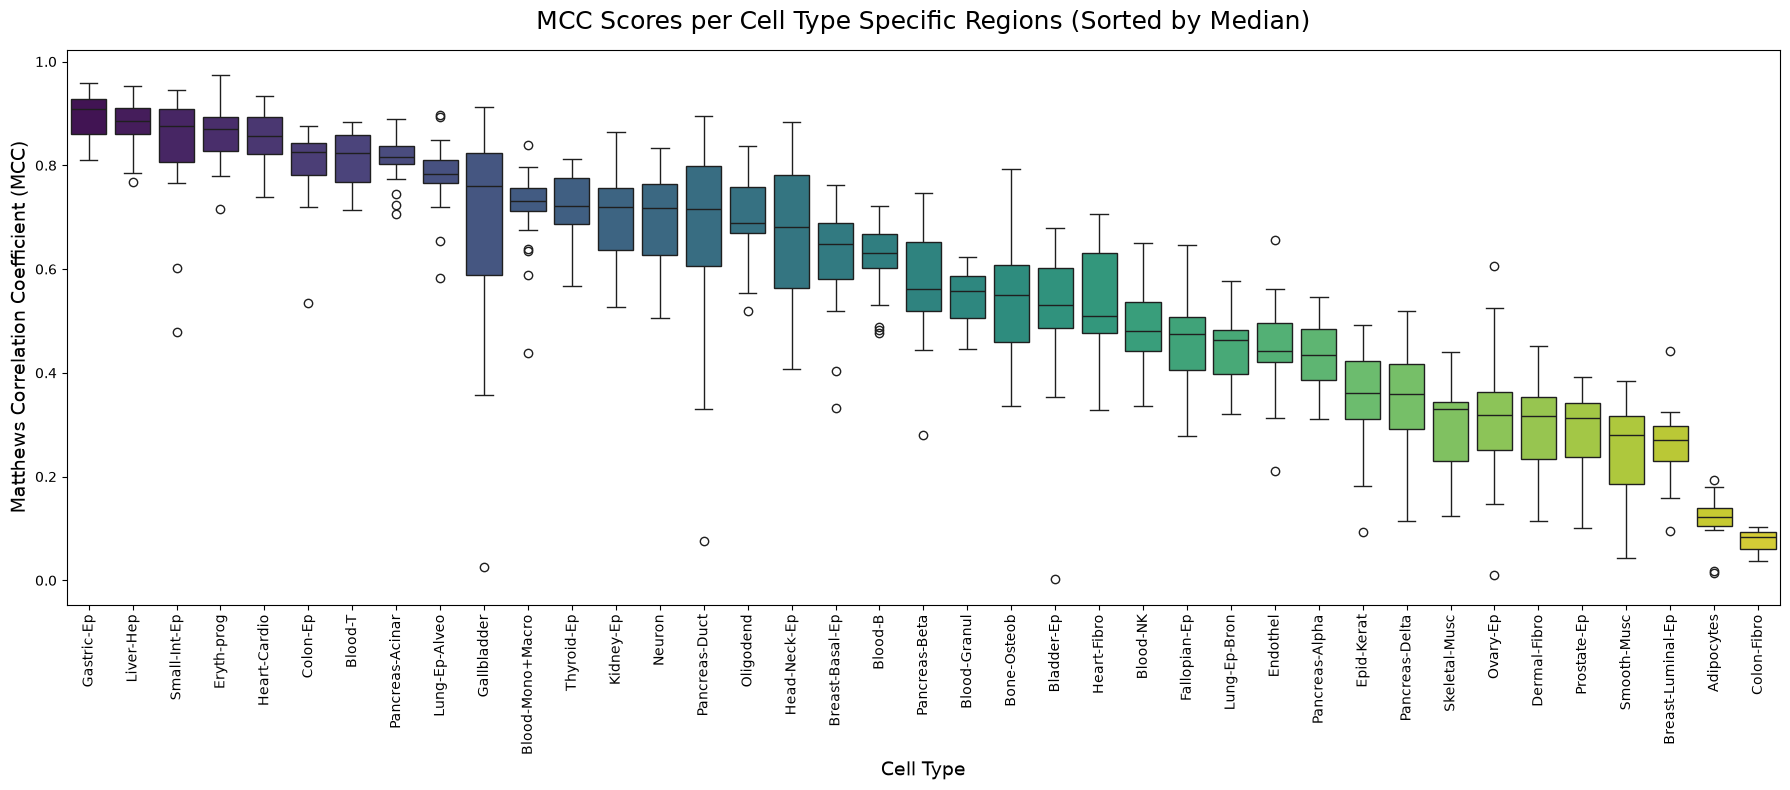

In [45]:
plot_sorted_mcc_boxplots(per_region_confidence, metric = "confidence_on_target")

In [48]:
reference_genome = "hg38"
original_atlas = UXMMethylationAtlas(atlas_name=f"UXMU25_{reference_genome}_l4", reference_genome=reference_genome, atlas_path=f"/home/luna.kuleuven.be/u0169940/Repos/UXM_deconv/supplemental/Atlas.U25.l4.{reference_genome}.full.tsv", ignore=["Megakaryocytes"])

In [49]:
import pandas as pd
import numpy as np
from scipy.stats import entropy


def score_methylation_regions(df):
    # Separate metadata columns from cell-type data columns
    metadata_cols = [
        "chr",
        "start",
        "end",
        "startCpG",
        "endCpG",
        "target",
        "name",
        "direction",
    ]
    cell_type_cols = [c for c in df.columns if c not in metadata_cols]

    results = []

    for idx, row in df.iterrows():
        target_cell = row["target"]

        # Extract target value and background values
        target_val = row[target_cell]
        obs_vals = row[cell_type_cols].astype(float).values
        bg_vals = [row[c] for c in cell_type_cols if c != target_cell]

        # 1. Basic Entropy
        # Normalize observed values to create a valid probability distribution
        obs_sum = np.sum(obs_vals)
        if obs_sum > 0:
            q_dist = obs_vals / obs_sum
        else:
            q_dist = np.ones_like(obs_vals) / len(
                obs_vals
            )  # uniform fallback if all are zero

        ent = entropy(q_dist, base=2)

        # 2. KL-Divergence
        # P is the ideal distribution (1 for target cell, 0 elsewhere)
        p_dist = np.zeros_like(obs_vals)
        target_idx = cell_type_cols.index(target_cell)
        p_dist[target_idx] = 1.0

        kl_div = entropy(p_dist, q_dist, base=2)

        # 3. Proxy GSC (Target - Max Background)
        max_bg = np.max(bg_vals)
        gss = target_val - max_bg

        # 4. Delta from Average Background (Target - Mean Background)
        mean_bg = np.mean(bg_vals)
        delta_avg = target_val - mean_bg

        results.append(
            {
                "name": row["name"],
                "entropy": ent,
                "kl_divergence": kl_div,
                "proxy_GSS": gss,
                "delta_avg_bg": delta_avg,
            }
        )

    # Convert results to DataFrame and merge with original
    res_df = pd.DataFrame(results)
    final_df = pd.merge(df, res_df, on="name")

    return final_df

In [75]:
scored_atlas = score_methylation_regions(original_atlas._atlas)

In [76]:
scored_atlas = pd.merge(scored_atlas, per_region_confidence, on="name")

In [57]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats


def plot_regression(x, y, x_label="X-axis", y_label="Y-axis"):
    """
    Plots a scatter plot of x and y, fits a linear regression line,
    and displays the R-squared value and regression equation.
    """
    # 1. Perform linear regression
    slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

    # 2. Calculate R-squared
    r_squared = r_value**2

    # 3. Create the fitted line data
    # Equation: y = mx + b
    line = slope * np.array(x) + intercept

    # 4. Visualization
    plt.figure(figsize=(10, 6))

    # Scatter plot of raw data
    plt.scatter(x, y, alpha=0.6, edgecolors="w", label="Data Points")

    # Regression line
    plt.plot(
        x,
        line,
        color="red",
        linewidth=2,
        label=f"Fitted Line: y={slope:.2f}x + {intercept:.2f}",
    )

    # 5. Add R2 Annotation
    # We place the text in the "upper left" of the plot area
    plt.text(
        0.05,
        0.95,
        f"$R^2 = {r_squared:.3f}$",
        transform=plt.gca().transAxes,
        fontsize=14,
        verticalalignment="top",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.5),
    )

    # Aesthetics
    plt.title(f"Linear Regression: {y_label} vs {x_label}", fontsize=16)
    plt.xlabel(x_label, fontsize=12)
    plt.ylabel(y_label, fontsize=12)
    plt.legend(loc="lower right")
    plt.grid(True, linestyle="--", alpha=0.7)

    plt.show()

In [77]:
scored_atlas = scored_atlas.dropna(subset=["proxy_GSS"])

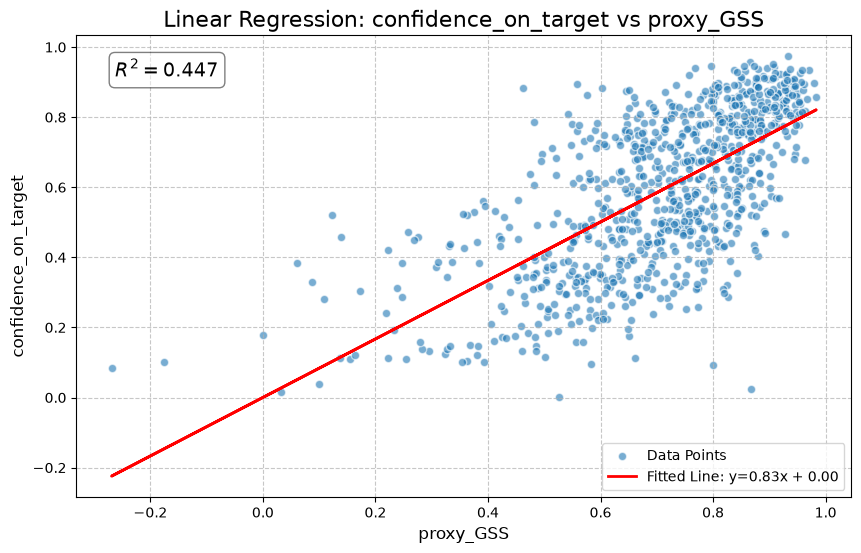

In [63]:
plot_regression(
    scored_atlas["proxy_GSS"],
    scored_atlas["confidence_on_target"],
    x_label="proxy_GSS",
    y_label="confidence_on_target",
)

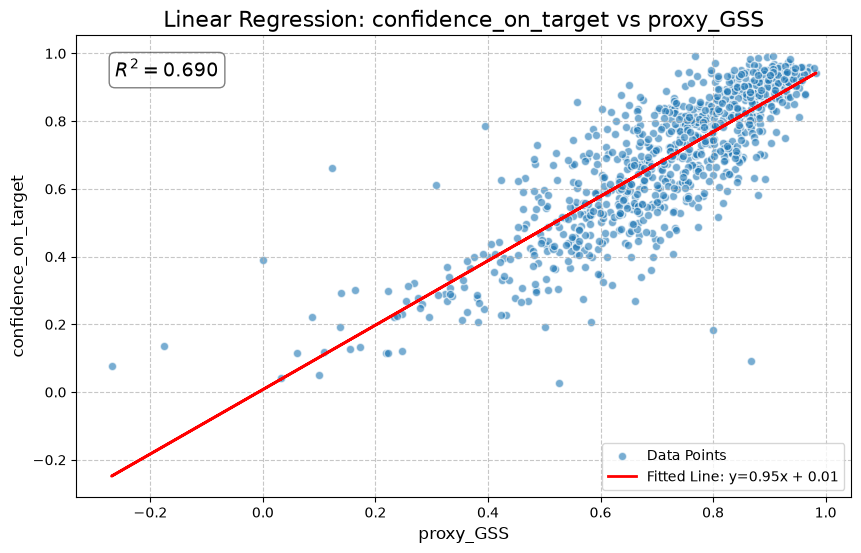

In [78]:
plot_regression(
    scored_atlas["proxy_GSS"],
    scored_atlas["confidence_on_target"],
    x_label="proxy_GSS",
    y_label="confidence_on_target",
)

In [122]:
per_celltype_r2= {'Adipocytes': 0.9766982793807983,
    'Bladder-Ep': 0.9798828959465027,
    'Blood-B': 0.9820882081985474,
    'Blood-Granul': 0.9961662888526917,
    'Blood-Mono+Macro': 0.9899080395698547,
    'Blood-NK': 0.9959220886230469,
    'Blood-T': 0.983995795249939,
    'Bone-Osteob': 0.9932330846786499,
    'Breast-Basal-Ep': 0.9829484224319458,
    'Breast-Luminal-Ep': 0.9906355142593384,
    'Colon-Ep': 0.9969695210456848,
    'Colon-Fibro': 0.8236932158470154,
    'Dermal-Fibro': 0.9733510613441467,
    'Endothel': 0.9527422785758972,
    'Epid-Kerat': 0.9942182898521423,
    'Eryth-prog': 0.9965729117393494,
    'Fallopian-Ep': 0.9622613787651062,
    'Gallbladder': 0.9518396854400635,
    'Gastric-Ep': 0.9972283244132996,
    'Head-Neck-Ep': 0.9963954091072083,
    'Heart-Cardio': 0.9971545338630676,
    'Heart-Fibro': 0.9946412444114685,
    'Kidney-Ep': 0.9955190420150757,
    'Liver-Hep': 0.9942318201065063,
    'Lung-Ep-Alveo': 0.9834399223327637,
    'Lung-Ep-Bron': 0.9933682680130005,
    'Neuron': 0.9863259792327881,
    'Oligodend': 0.9966501593589783,
    'Ovary-Ep': 0.8796976804733276,
    'Pancreas-Acinar': 0.9963768720626831,
    'Pancreas-Alpha': 0.9951455593109131,
    'Pancreas-Beta': 0.9945254325866699,
    'Pancreas-Delta': 0.9945425987243652,
    'Pancreas-Duct': 0.995949923992157,
    'Prostate-Ep': 0.9548659920692444,
    'Skeletal-Musc': 0.99310302734375,
    'Small-Int-Ep': 0.9967523217201233,
    'Smooth-Musc': 0.9587547183036804,
    'Thyroid-Ep': 0.9968989491462708}


per_celltype_r2_soft = {'Adipocytes': 0.982833981513977,
    'Bladder-Ep': 0.9805876016616821,
    'Blood-B': 0.9626935720443726,
    'Blood-Granul': 0.9970414638519287,
    'Blood-Mono+Macro': 0.9922277927398682,
    'Blood-NK': 0.9964792728424072,
    'Blood-T': 0.9900214672088623,
    'Bone-Osteob': 0.9968034029006958,
    'Breast-Basal-Ep': 0.9843273162841797,
    'Breast-Luminal-Ep': 0.9950091242790222,
    'Colon-Ep': 0.9971425533294678,
    'Colon-Fibro': 0.8423721194267273,
    'Dermal-Fibro': 0.9745991230010986,
    'Endothel': 0.9543002843856812,
    'Epid-Kerat': 0.9947177171707153,
    'Eryth-prog': 0.9966893792152405,
    'Fallopian-Ep': 0.970394492149353,
    'Gallbladder': 0.977540910243988,
    'Gastric-Ep': 0.997646152973175,
    'Head-Neck-Ep': 0.9965903162956238,
    'Heart-Cardio': 0.9976819753646851,
    'Heart-Fibro': 0.9951790571212769,
    'Kidney-Ep': 0.9955169558525085,
    'Liver-Hep': 0.9960127472877502,
    'Lung-Ep-Alveo': 0.9867797493934631,
    'Lung-Ep-Bron': 0.9951443672180176,
    'Neuron': 0.9886364936828613,
    'Oligodend': 0.996579110622406,
    'Ovary-Ep': 0.9171573519706726,
    'Pancreas-Acinar': 0.996953547000885,
    'Pancreas-Alpha': 0.9956986904144287,
    'Pancreas-Beta': 0.9950591325759888,
    'Pancreas-Delta': 0.996637761592865,
    'Pancreas-Duct': 0.9964710474014282,
    'Prostate-Ep': 0.9622601866722107,
    'Skeletal-Musc': 0.9948291182518005,
    'Small-Int-Ep': 0.9965125918388367,
    'Smooth-Musc': 0.964476466178894,
    'Thyroid-Ep': 0.9971280097961426}


uxm_r2 =  {'Adipocytes': 0.8352005503251015,
    'Bladder-Ep': 0.9342071969553257,
    'Blood-B': 0.9489645428234532,
    'Blood-Granul': 0.9910981318715536,
    'Blood-Mono+Macro': 0.9843662788208397,
    'Blood-NK': 0.9760014956218405,
    'Blood-T': 0.9685719051763761,
    'Bone-Osteob': 0.9381745105493986,
    'Breast-Basal-Ep': 0.9941326650463191,
    'Breast-Luminal-Ep': 0.981325878431086,
    'Colon-Ep': 0.9913935304147069,
    'Colon-Fibro': 0.4875211522574755,
    'Dermal-Fibro': 0.7568184565106842,
    'Endothel': 0.8972632890628371,
    'Epid-Kerat': 0.9794674278685236,
    'Eryth-prog': 0.973536591582972,
    'Fallopian-Ep': 0.9651068321435358,
    'Gallbladder': 0.989776429889946,
    'Gastric-Ep': 0.9936631133754702,
    'Head-Neck-Ep': 0.9899743395568756,
    'Heart-Cardio': 0.9865206984553503,
    'Heart-Fibro': 0.9436894667434408,
    'Kidney-Ep': 0.9747999137551329,
    'Liver-Hep': 0.9954835998957884,
    'Lung-Ep-Alveo': 0.9967341955502166,
    'Lung-Ep-Bron': 0.9903998110769318,
    'Neuron': 0.9933620975434395,
    'Oligodend': 0.9811292696502723,
    'Ovary-Ep': 0.8912818735360833,
    'Pancreas-Acinar': 0.9787673059587969,
    'Pancreas-Alpha': 0.9923198069186491,
    'Pancreas-Beta': 0.9689543457166372,
    'Pancreas-Delta': 0.9786886849679789,
    'Pancreas-Duct': 0.9851922347319416,
    'Prostate-Ep': 0.9265971553020894,
    'Skeletal-Musc': 0.9505625419367099,
    'Small-Int-Ep': 0.9856861764738898,
    'Smooth-Musc': 0.9287515038082516,
    'Thyroid-Ep': 0.9861465863704008}

In [83]:
gcs_aggregateed = scored_atlas[["target", "proxy_GSS"]].groupby("target").agg(np.mean).reset_index()

/tmp/ipykernel_4082976/65044646.py:1: FutureWarning: The provided callable <function mean at 0x71adfd3d0680> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  gcs_aggregateed = scored_atlas[["target", "proxy_GSS"]].groupby("target").agg(np.mean).reset_index()


In [123]:
gcs_aggregateed["hard_r2"] = gcs_aggregateed["target"].apply(lambda x: per_celltype_r2[x])
gcs_aggregateed["soft_r2"] = gcs_aggregateed["target"].apply(lambda x: per_celltype_r2_soft[x])
gcs_aggregateed["uxm_r2"] = gcs_aggregateed["target"].apply(lambda x: uxm_r2[x])

In [98]:
from scipy.stats import spearmanr

In [ ]:
spearmanr(gcs_aggregateed["proxy_GSS"],
    gcs_aggregateed["hard_r2"])

SignificanceResult(statistic=np.float64(0.6082995951417005), pvalue=np.float64(3.9894689498910164e-05))

In [102]:
spearmanr(gcs_aggregateed["proxy_GSS"],
    gcs_aggregateed["soft_r2"])

SignificanceResult(statistic=np.float64(0.6238866396761134), pvalue=np.float64(2.199985399857107e-05))

In [124]:
spearmanr(gcs_aggregateed["proxy_GSS"],
    gcs_aggregateed["uxm_r2"])

SignificanceResult(statistic=np.float64(0.5785425101214575), pvalue=np.float64(0.00011437074009614491))

In [140]:
gcs_aggregateed["soft_r2"].sort_values()[:5]

11    0.842372
28    0.917157
13    0.954300
34    0.962260
2     0.962694
Name: soft_r2, dtype: float64

In [139]:
gcs_aggregateed["hard_r2"].sort_values()[:5]

11    0.823693
28    0.879698
17    0.951840
13    0.952742
34    0.954866
Name: hard_r2, dtype: float64

In [138]:
gcs_aggregateed["uxm_r2"].sort_values()[:5]

11    0.487521
12    0.756818
0     0.835201
28    0.891282
13    0.897263
Name: uxm_r2, dtype: float64

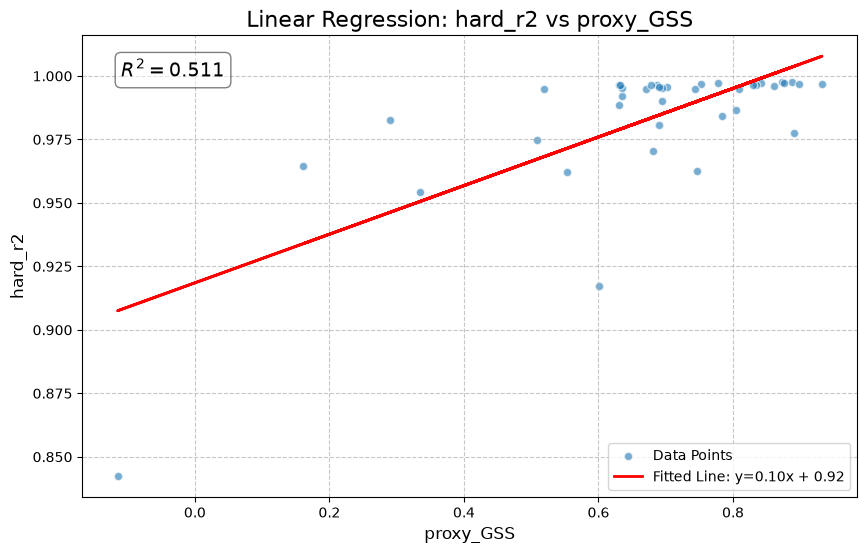

In [127]:
plot_regression(
    gcs_aggregateed["proxy_GSS"],
    gcs_aggregateed["soft_r2"],
    x_label="proxy_GSS",
    y_label="hard_r2",
)

### UXM Results

In [106]:
data_path = "/mnt/data/syto_experiments/mlflow/198121009408531961/1f0aaa3947bb4732a945e76aed3a5864/artifacts/baselines_deconvolution/uxm_trainonly_atlas/uxm/test_deconvolution_results.parquet"
uxm_res = pd.read_parquet(data_path)

In [108]:
from edautils import plot_deconvolution_results

In [109]:
import json
labels_dict_path = "/home/luna.kuleuven.be/u0169940/Repos/syto/App/labels_dict.json"
with open(labels_dict_path, "r", encoding="utf-8") as f:
            # JSON keys are strings; convert to {int: str}
            labels_dict = json.load(f)

In [111]:
keys = labels_dict.keys()
for key in keys:
    labels_dict[int(key)] = labels_dict.pop(key)

(<Figure size 2000x1000 with 2 Axes>,
 {'celltype_metrics': {'overall_r2': 0.9485704881793489,
   'per_celltype_r2': {'Adipocytes': 0.8352005503251015,
    'Bladder-Ep': 0.9342071969553257,
    'Blood-B': 0.9489645428234532,
    'Blood-Granul': 0.9910981318715536,
    'Blood-Mono+Macro': 0.9843662788208397,
    'Blood-NK': 0.9760014956218405,
    'Blood-T': 0.9685719051763761,
    'Bone-Osteob': 0.9381745105493986,
    'Breast-Basal-Ep': 0.9941326650463191,
    'Breast-Luminal-Ep': 0.981325878431086,
    'Colon-Ep': 0.9913935304147069,
    'Colon-Fibro': 0.4875211522574755,
    'Dermal-Fibro': 0.7568184565106842,
    'Endothel': 0.8972632890628371,
    'Epid-Kerat': 0.9794674278685236,
    'Eryth-prog': 0.973536591582972,
    'Fallopian-Ep': 0.9651068321435358,
    'Gallbladder': 0.989776429889946,
    'Gastric-Ep': 0.9936631133754702,
    'Head-Neck-Ep': 0.9899743395568756,
    'Heart-Cardio': 0.9865206984553503,
    'Heart-Fibro': 0.9436894667434408,
    'Kidney-Ep': 0.97479991375513

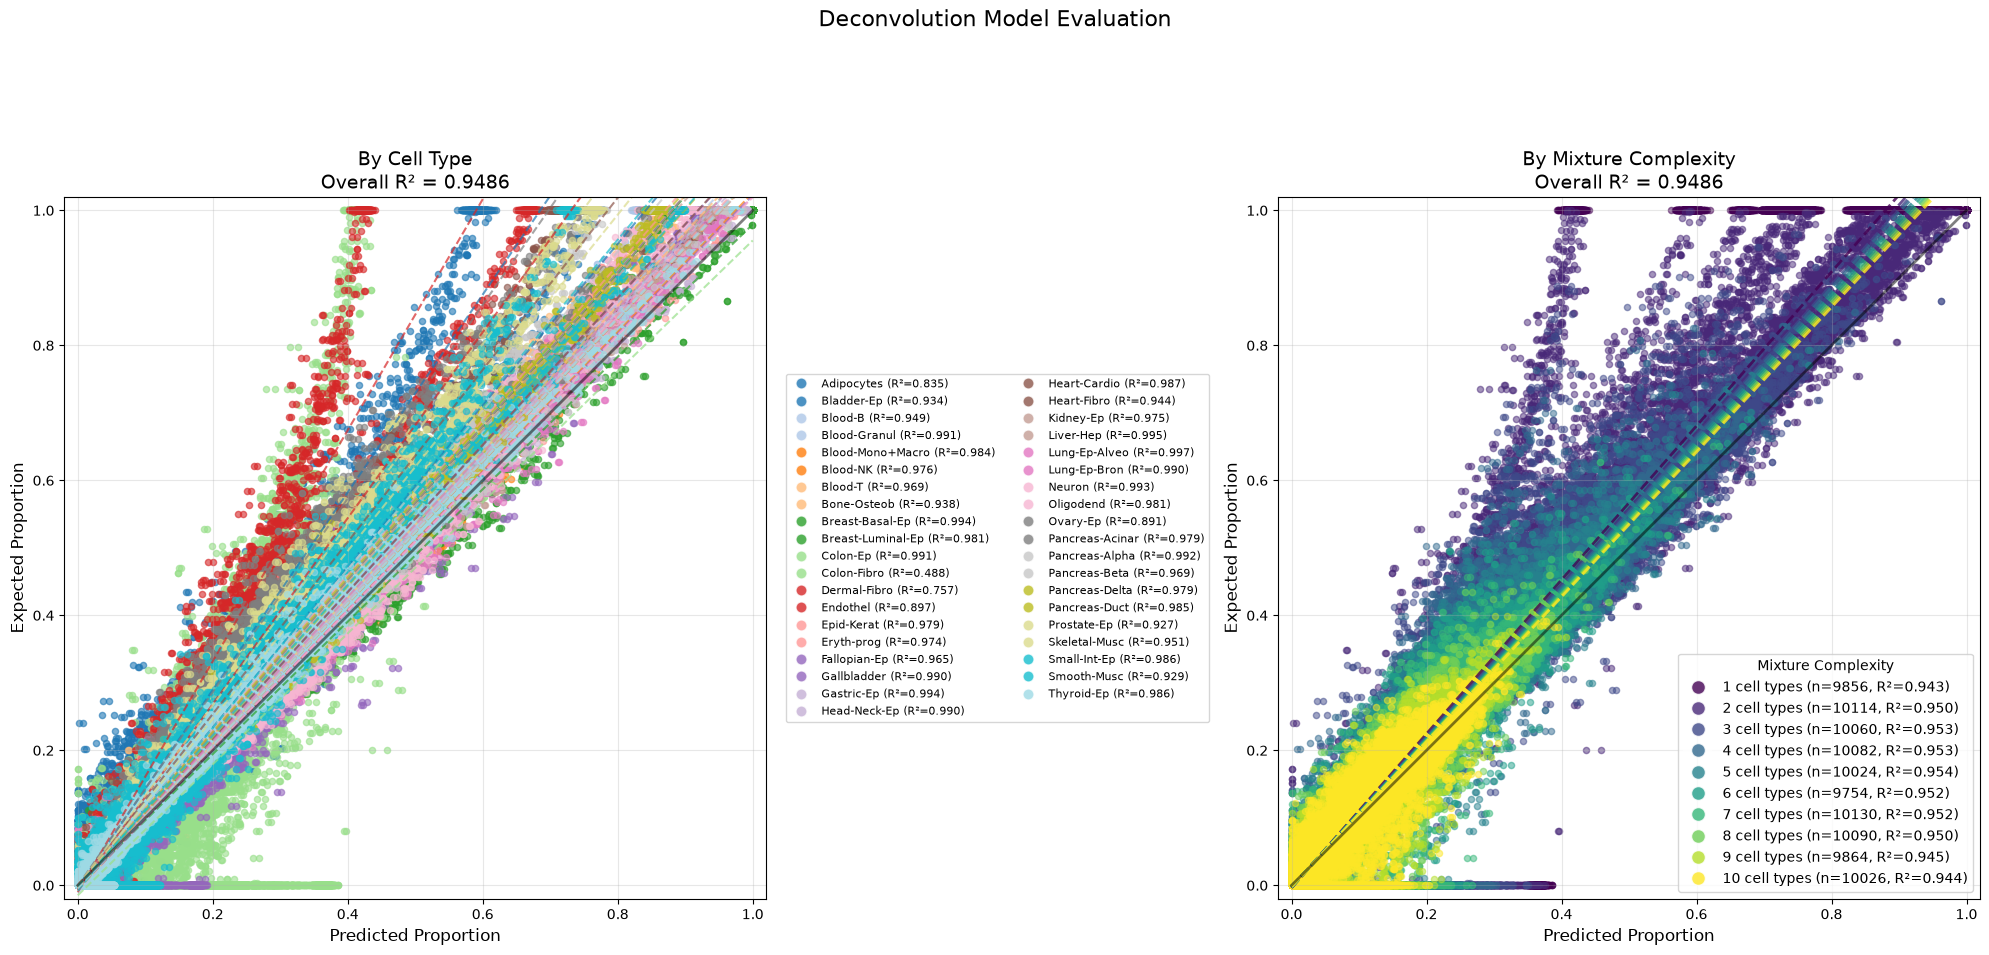

In [118]:
plot_deconvolution_results(uxm_res["target_proportion"].to_numpy().reshape(100000,39), 
                           uxm_res["uxm"].to_numpy().reshape(100000,39), labels_dict=labels_dict)